  Thinning (factor=2): kept 251 points
Loaded 1024pi.out: angle=0.0°, Fx=3.217e+03, Fy=0.000e+00, components=x, n_points=251
Added experimental noise: 2% of peak |data|=27.13 -> sigma_noise_added=0.5426, realized sigma_noise=0.5096 
Automatic sigma prior scale: max fitted displacement=27.1284, 10% max displacement=2.71284, beta=1/(10% max displacement)=0.368617
sigma_noise prior: Exp(beta=0.3686)
Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\data_vs_noise.pdf


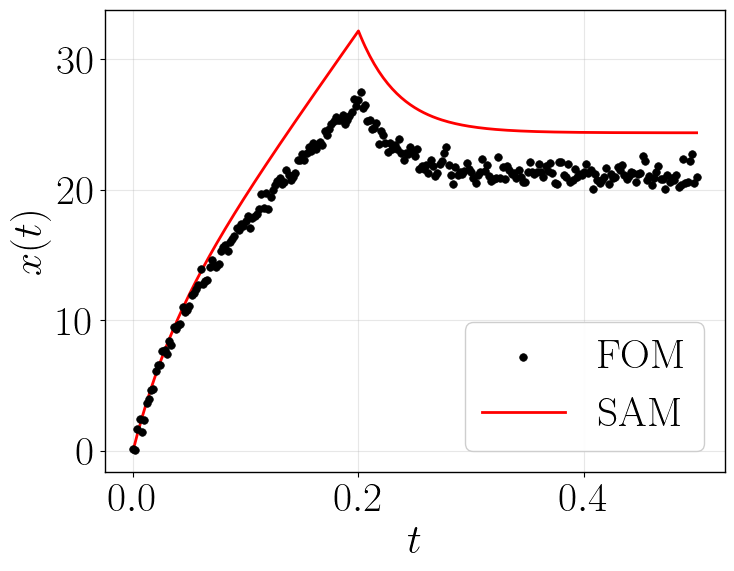

Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\prior.pdf


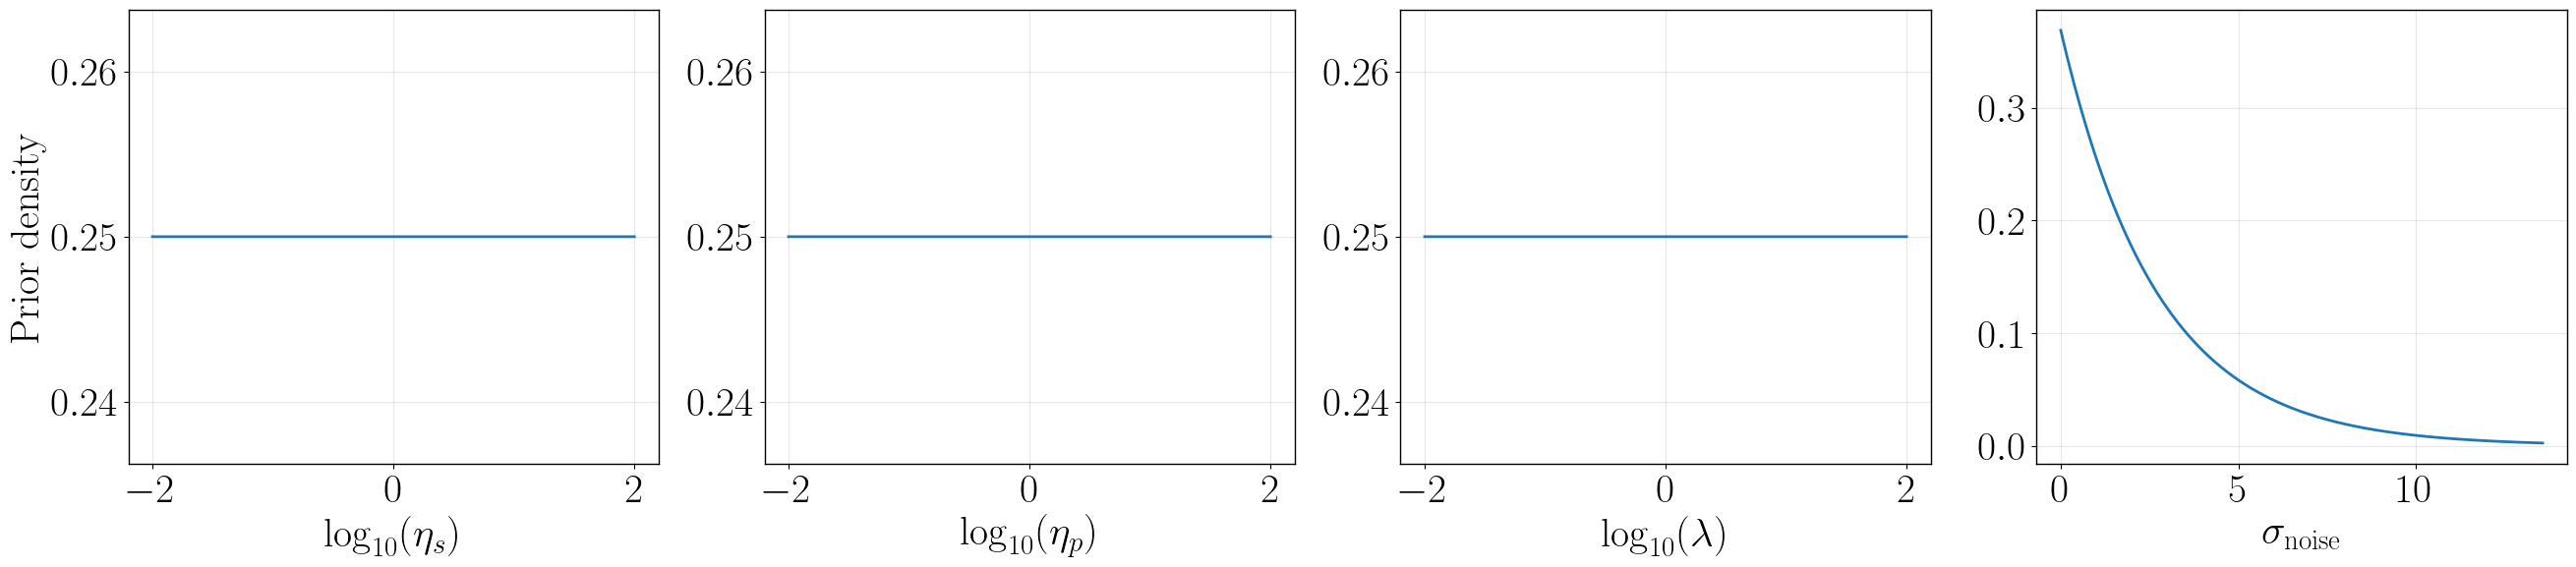


Preparing MCMC: ndim=4, walkers=8, steps=5000, init=kmeans, warmup=True

Initial walkers (physical):
  00: [0.06853817 0.1375507  1.1896034  1.07766196]
  01: [0.83575562 0.09178011 3.05539172 3.73488571]
  02: [7.56276052 0.14522499 0.12702904 1.19513396]
  03: [ 0.21547243  1.10617351  2.23482241 11.4055184 ]
  04: [ 2.80649196  5.4793214  18.97122723  1.30242699]
  05: [1.09212745 7.77105884 0.25459778 4.31133494]
  06: [ 0.45973801 15.93668319  0.17007873  1.26378424]
  07: [1.72378909 1.03832973 0.99335674 7.33561149]

Warm-up: 500 steps x 8 walkers


Warm-up:   0%|          | 0/500 [00:00<?, ?it/s]


Walkers after warm-up (physical):
  00: [0.46049253 1.17606939 0.08233791 0.39466934]
  01: [0.39483908 1.18517109 0.08672946 0.61995621]
  02: [0.42853263 1.19219391 0.09432816 0.55276392]
  03: [0.43502683 1.14700534 0.0803619  0.582457  ]
  04: [0.43324755 1.17383442 0.08366138 0.50461897]
  05: [0.50152904 1.13666556 0.07489259 0.65193477]
  06: [0.39227698 1.16461986 0.09460045 0.5913656 ]
  07: [0.45260105 1.09985092 0.09104722 0.65869583]


MCMC:   0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
import numpy as np
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from packages.main import  InferenceProcedure

from packages.main import InferenceProcedure
import numpy as np

model = InferenceProcedure(
    force=8*np.pi,
    material_model="viscoelastic",
    boundary_model="unbounded",
    theta=0,
    a=1.0,
    t_unload=0.2,
    sigma_noise_percent=2.0,
    sigma_bias = None,
    nsteps=5000,
    thin_factor=6)

model.load_data("data/nonlinear_viscoelastic/1024pi.out", force=1024*np.pi, append=True, thin_factor=2)
model.plot_data(theta_true=[0.5, 0.9, 0.1])
model.plot_prior()
model.run_mcmc(init_method="kmeans")
model.plot_results()